# Final Store-Level Forecasting



## Objective

Forecast daily visitors for each `air_store_id` and test whether a store-level `ARIMAX` model can outperform a strong weekly seasonal baseline.

## Final Modeling Design

- Unit of forecasting: individual `air_store_id`
- Baseline: `Seasonal Naive (lag = 7)`
- Final model: `ARIMAX(1,1,1)(1,1,1)[7]`
- Exogenous features: `is_holiday`, `is_golden_week`, `is_weekend`, `log1p_reserve`
- Reservation source: `AIR + mapped HPG`
- Final holdout: `2017-03-15 -> 2017-04-22`

## Why This Setup

- EDA showed strong weekly seasonality, so a lag-7 baseline is the right benchmark.
- The target is right-skewed, so the series is modeled on the `log1p` scale.
- Holiday and reservation features were retained because they are plausible demand drivers beyond weekly repetition.
- The corrected pipeline avoids synthetic pre-history and caps holdout reservation inputs at the forecast origin to avoid leakage.

## Evaluation Strategy

This notebook reports two levels of evaluation:

1. **One lightweight expanding-window validation fold** to show that the model can generalize to an earlier time split without making runtime too heavy.
2. **Final observed holdout evaluation** for the last available out-of-sample period.



In [8]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

CWD = Path.cwd()
if (CWD / 'processed_data').exists():
    NOTEBOOK_DIR = CWD
    REPO_DIR = CWD.parent
elif (CWD / 'notebooks' / 'processed_data').exists():
    REPO_DIR = CWD
    NOTEBOOK_DIR = CWD / 'notebooks'
else:
    raise FileNotFoundError('Cannot locate notebooks/processed_data from the current working directory.')

DATA_DIR = NOTEBOOK_DIR / 'processed_data'
OUTPUT_DIR = REPO_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')

print('REPO_DIR   :', REPO_DIR)
print('NOTEBOOK_DIR:', NOTEBOOK_DIR)
print('processed_data exists:', DATA_DIR.exists())
print('output exists        :', OUTPUT_DIR.exists())


BASE_DIR   : d:\Downloads\time_series_project_2\Store-Level-Time-Series-Forecasting-of-Restaurant-Visitors-Using-ARIMAX
processed_data exists: True
outputs exists       : True


## Load Inputs


In [9]:
visits = pd.read_csv(DATA_DIR / 'air_visits.csv')
air_reserves = pd.read_csv(DATA_DIR / 'air_reserve.csv')
hpg_reserves = pd.read_csv(DATA_DIR / 'hpg_reserve.csv')
store_ids_map = pd.read_csv(DATA_DIR / 'store_ids.csv')
holidays = pd.read_csv(DATA_DIR / 'holidays.csv')
stores = pd.read_csv(DATA_DIR / 'air_store.csv')

visits['visit_date'] = pd.to_datetime(visits['visit_date'])
visits['visitors'] = pd.to_numeric(visits['visitors'])

air_reserves['visit_datetime'] = pd.to_datetime(air_reserves['visit_datetime'])
air_reserves['reserve_datetime'] = pd.to_datetime(air_reserves['reserve_datetime'])
air_reserves['air_store_id'] = air_reserves['air_store_id'].astype(str)

hpg_reserves['visit_datetime'] = pd.to_datetime(hpg_reserves['visit_datetime'])
hpg_reserves['reserve_datetime'] = pd.to_datetime(hpg_reserves['reserve_datetime'])
hpg_reserves = hpg_reserves.merge(store_ids_map, on='hpg_store_id', how='inner')
hpg_reserves = hpg_reserves[['air_store_id', 'visit_datetime', 'reserve_datetime', 'reserve_visitors']]

reserves = pd.concat([air_reserves, hpg_reserves], ignore_index=True)
reserves = reserves.loc[reserves['reserve_datetime'] <= reserves['visit_datetime']].copy()
reserves['visit_date'] = reserves['visit_datetime'].dt.normalize()

holiday_date_col = 'visit_date' if 'visit_date' in holidays.columns else 'calendar_date'
holidays['visit_date'] = pd.to_datetime(holidays[holiday_date_col])
if 'holiday_flg' in holidays.columns and 'is_holiday' not in holidays.columns:
    holidays['is_holiday'] = holidays['holiday_flg']

holidays['is_holiday'] = pd.to_numeric(holidays['is_holiday']).astype(float)
holidays['is_weekend'] = holidays['visit_date'].dt.dayofweek.isin([5, 6]).astype(float)
holidays['is_golden_week'] = (
    (((holidays['visit_date'].dt.month == 4) & (holidays['visit_date'].dt.day >= 29)) |
     ((holidays['visit_date'].dt.month == 5) & (holidays['visit_date'].dt.day <= 5))).astype(float)
)

print('visits        :', visits.shape)
print('air_reserves  :', air_reserves.shape)
print('hpg_reserves  :', hpg_reserves.shape)
print('combined_resv :', reserves.shape)
print('holidays      :', holidays.shape)
print('stores        :', stores.shape)
display(visits.head())



visits        : (251220, 5)
air_reserves  : (85661, 4)
hpg_reserves  : (27960, 4)
combined_resv : (113621, 5)
holidays      : (517, 8)
stores        : (829, 5)


,air_store_id,visit_date,visitors,wday,month
0,air_ba937bf13d40fb24,2016-01-13,25,Wed,Jan
1,air_ba937bf13d40fb24,2016-01-14,32,Thu,Jan
2,air_ba937bf13d40fb24,2016-01-15,29,Fri,Jan
3,air_ba937bf13d40fb24,2016-01-16,22,Sat,Jan
4,air_ba937bf13d40fb24,2016-01-18,6,Mon,Jan


## Helper Functions


In [10]:
def seasonal_naive_forecast(train_vals: np.ndarray, horizon: int, season: int = 7) -> np.ndarray:
    hist = list(train_vals)
    preds = []
    for _ in range(horizon):
        pred = hist[-season]
        preds.append(pred)
        hist.append(pred)
    return np.asarray(preds, dtype=float)


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def build_reserve_features(reserves: pd.DataFrame, cutoff_datetime: pd.Timestamp | None = None) -> pd.DataFrame:
    df = reserves.copy()
    if cutoff_datetime is not None:
        df = df.loc[df['reserve_datetime'] <= cutoff_datetime].copy()
    reserve_agg = (
        df.groupby(['air_store_id', 'visit_date'], as_index=False)
        .agg(total_reserve_visitors=('reserve_visitors', 'sum'))
    )
    reserve_agg['log1p_reserve'] = np.log1p(reserve_agg['total_reserve_visitors'])
    return reserve_agg


def build_store_daily_frame(
    store_id: str,
    visits: pd.DataFrame,
    reserve_agg_full: pd.DataFrame,
    reserve_agg_capped: pd.DataFrame,
    holidays: pd.DataFrame,
) -> pd.DataFrame:
    store_visits = visits.loc[visits['air_store_id'] == store_id, ['visit_date', 'visitors']].copy()
    store_visits = store_visits.sort_values('visit_date')
    start_date = store_visits['visit_date'].min()
    end_date = store_visits['visit_date'].max()

    grid = pd.DataFrame({'visit_date': pd.date_range(start_date, end_date, freq='D')})
    df = grid.merge(store_visits, on='visit_date', how='left')

    df['visitors'] = df['visitors'].fillna(0.0).astype(float)
    df['log1p_visitors'] = np.log1p(df['visitors'])

    df = df.merge(
        holidays[['visit_date', 'is_holiday', 'is_weekend', 'is_golden_week']],
        on='visit_date',
        how='left',
    )
    df[['is_holiday', 'is_weekend', 'is_golden_week']] = df[['is_holiday', 'is_weekend', 'is_golden_week']].fillna(0.0).astype(float)

    full_store_reserve = reserve_agg_full.loc[reserve_agg_full['air_store_id'] == store_id, ['visit_date', 'log1p_reserve']]
    capped_store_reserve = reserve_agg_capped.loc[reserve_agg_capped['air_store_id'] == store_id, ['visit_date', 'log1p_reserve']]

    df = df.merge(full_store_reserve.rename(columns={'log1p_reserve': 'log1p_reserve_train'}), on='visit_date', how='left')
    df = df.merge(capped_store_reserve.rename(columns={'log1p_reserve': 'log1p_reserve_test'}), on='visit_date', how='left')
    df['log1p_reserve_train'] = df['log1p_reserve_train'].fillna(0.0).astype(float)
    df['log1p_reserve_test'] = df['log1p_reserve_test'].fillna(0.0).astype(float)
    df['air_store_id'] = store_id
    return df


def build_exog(train: pd.DataFrame, test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    x_train = train[['is_holiday', 'is_golden_week', 'is_weekend', 'log1p_reserve_train']].rename(
        columns={'log1p_reserve_train': 'log1p_reserve'}
    ).astype(float)
    x_test = test[['is_holiday', 'is_golden_week', 'is_weekend', 'log1p_reserve_test']].rename(
        columns={'log1p_reserve_test': 'log1p_reserve'}
    ).astype(float)
    return x_train, x_test


def fit_arimax_forecast(y_train: pd.Series, x_train: pd.DataFrame, x_test: pd.DataFrame) -> tuple[np.ndarray, float, str]:
    fit = SARIMAX(
        y_train,
        exog=x_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=50)
    preds_log = np.asarray(fit.forecast(steps=len(x_test), exog=x_test), dtype=float)
    return preds_log, float(fit.aic), 'ARIMAX'


def evaluate_store_split(
    store_id: str,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
    reserve_agg_full: pd.DataFrame,
    reserve_agg_capped: pd.DataFrame,
    min_train_days: int = 90,
) -> tuple[dict | None, pd.DataFrame | None, dict | None]:
    df = build_store_daily_frame(store_id, visits, reserve_agg_full, reserve_agg_capped, holidays)
    train = df.loc[df['visit_date'] <= train_end].copy()
    test = df.loc[(df['visit_date'] >= test_start) & (df['visit_date'] <= test_end)].copy()

    if len(train) < min_train_days or len(test) == 0:
        return None, None, {
            'air_store_id': store_id,
            'train_days': int(len(train)),
            'test_days': int(len(test)),
            'reason': 'insufficient_train_or_no_test_rows',
        }

    y_train = train['log1p_visitors'].astype(float)
    y_test = test['visitors'].astype(float).to_numpy()
    y_test_log = test['log1p_visitors'].astype(float).to_numpy()
    x_train, x_test = build_exog(train, test)

    baseline_log = seasonal_naive_forecast(y_train.to_numpy(), len(test), season=7)
    baseline_pred = np.expm1(baseline_log)

    try:
        arimax_log, arimax_aic, arimax_status = fit_arimax_forecast(y_train, x_train, x_test)
        arimax_pred = np.expm1(arimax_log)
    except Exception as exc:
        arimax_log = baseline_log.copy()
        arimax_pred = baseline_pred.copy()
        arimax_aic = np.nan
        arimax_status = f'ARIMAX_fallback_to_baseline: {exc}'

    metrics_row = {
        'air_store_id': store_id,
        'train_days': int(len(train)),
        'test_days': int(len(test)),
        'seasonal_naive_rmsle': rmsle(y_test, baseline_pred),
        'arimax_rmsle': rmsle(y_test, arimax_pred),
        'seasonal_naive_rmse_log': float(np.sqrt(np.mean((y_test_log - baseline_log) ** 2))),
        'arimax_rmse_log': float(np.sqrt(np.mean((y_test_log - arimax_log) ** 2))),
        'seasonal_naive_mape': float(np.mean(np.abs((y_test - baseline_pred) / np.clip(y_test, 1, None))) * 100.0),
        'arimax_mape': float(np.mean(np.abs((y_test - arimax_pred) / np.clip(y_test, 1, None))) * 100.0),
        'arimax_aic': arimax_aic,
        'arimax_status': arimax_status,
    }

    pred_chunk = pd.DataFrame({
        'air_store_id': store_id,
        'visit_date': test['visit_date'].dt.strftime('%Y-%m-%d'),
        'actual_visitors': y_test,
        'seasonal_naive_pred': baseline_pred,
        'arimax_pred': arimax_pred,
        'actual_log1p': y_test_log,
        'seasonal_naive_log1p': baseline_log,
        'arimax_log1p': arimax_log,
    })
    return metrics_row, pred_chunk, None


def evaluate_split(
    split_name: str,
    train_end: str,
    test_start: str,
    test_end: str,
    reserve_agg_full: pd.DataFrame,
    min_train_days: int = 90,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    train_end_ts = pd.Timestamp(train_end)
    test_start_ts = pd.Timestamp(test_start)
    test_end_ts = pd.Timestamp(test_end)
    capped_cutoff = train_end_ts + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    reserve_agg_capped = build_reserve_features(reserves, cutoff_datetime=capped_cutoff)

    rows = []
    chunks = []
    skipped = []

    for store_id in store_ids:
        row, chunk, skip = evaluate_store_split(
            store_id,
            train_end=train_end_ts,
            test_start=test_start_ts,
            test_end=test_end_ts,
            reserve_agg_full=reserve_agg_full,
            reserve_agg_capped=reserve_agg_capped,
            min_train_days=min_train_days,
        )
        if skip is not None:
            skipped.append(skip)
            continue
        rows.append(row)
        chunks.append(chunk)

    metrics = pd.DataFrame(rows).merge(store_meta, on='air_store_id', how='left')
    preds = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    skipped_df = pd.DataFrame(skipped)

    summary = {
        'split': split_name,
        'train_end': train_end,
        'test_start': test_start,
        'test_end': test_end,
        'n_stores_evaluated': int(len(metrics)),
        'n_stores_skipped': int(len(skipped_df)),
        'pooled_rows': int(len(preds)),
        'seasonal_naive_rmsle': rmsle(preds['actual_visitors'], preds['seasonal_naive_pred']) if len(preds) else np.nan,
        'arimax_rmsle': rmsle(preds['actual_visitors'], preds['arimax_pred']) if len(preds) else np.nan,
        'seasonal_naive_mape': float(np.mean(np.abs((preds['actual_visitors'] - preds['seasonal_naive_pred']) / np.clip(preds['actual_visitors'], 1, None))) * 100.0) if len(preds) else np.nan,
        'arimax_mape': float(np.mean(np.abs((preds['actual_visitors'] - preds['arimax_pred']) / np.clip(preds['actual_visitors'], 1, None))) * 100.0) if len(preds) else np.nan,
        'arimax_better_store_share': float((metrics['arimax_rmsle'] < metrics['seasonal_naive_rmsle']).mean()) if len(metrics) else np.nan,
    }
    summary['improvement_pct'] = 100.0 * (summary['seasonal_naive_rmsle'] - summary['arimax_rmsle']) / summary['seasonal_naive_rmsle']
    return metrics, preds, skipped_df, summary

print('Helpers loaded.')



Helpers loaded.


## Build Store-Level Features and Evaluation Windows


In [11]:
final_split_date = pd.Timestamp('2017-03-14')
final_holdout_start = pd.Timestamp('2017-03-15')
final_holdout_end = pd.Timestamp('2017-04-22')
reserve_agg_full = build_reserve_features(reserves)
reserve_agg_final = build_reserve_features(
    reserves,
    cutoff_datetime=final_split_date + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1),
)
store_meta = stores[['air_store_id', 'air_genre_name', 'air_area_name']].copy()
store_ids = sorted(visits['air_store_id'].unique())

observed_span = visits.groupby('air_store_id')['visit_date'].agg(['min', 'max', 'size']).reset_index()
observed_span['prehistory_days_removed'] = (observed_span['min'] - visits['visit_date'].min()).dt.days.clip(lower=0)

cv_folds = [
    {'split': 'CV1', 'train_end': '2017-01-31', 'test_start': '2017-02-01', 'test_end': '2017-02-07'},
]

print('n_stores                   :', len(store_ids))
print('global visit range         :', visits['visit_date'].min().date(), '->', visits['visit_date'].max().date())
print('final holdout              :', final_holdout_start.date(), '->', final_holdout_end.date())
print('reserve_agg_full           :', reserve_agg_full.shape)
print('reserve_agg_final          :', reserve_agg_final.shape)
print('stores with removed padding:', int((observed_span['prehistory_days_removed'] > 0).sum()))
display(observed_span.head())
display(pd.DataFrame(cv_folds))



n_stores                   : 814
global visit range         : 2016-01-01 -> 2017-04-22
final holdout              : 2017-03-15 -> 2017-04-22
reserve_agg_full           : (42193, 4)
reserve_agg_final          : (36651, 4)
stores with removed padding: 766


,air_store_id,min,max,size,prehistory_days_removed
0,air_00a91d42b08b08d9,2016-07-01,2017-04-22,232,182
1,air_0164b9927d20bcc3,2016-10-03,2017-04-22,149,276
2,air_0241aa3964b7f861,2016-01-03,2017-04-22,396,2
3,air_0328696196e46f18,2016-07-03,2017-04-22,116,184
4,air_034a3d5b40d5b1b1,2016-07-01,2017-04-22,251,182


,split,train_end,test_start,test_end
0,CV1,2017-01-31,2017-02-01,2017-02-07


## Inspect One Store Before the Full Run


In [12]:
sample_store_id = store_ids[0]
sample_df = build_store_daily_frame(sample_store_id, visits, reserve_agg_full, reserve_agg_final, holidays)
sample_train = sample_df.loc[sample_df['visit_date'] <= final_split_date].copy()
sample_test = sample_df.loc[sample_df['visit_date'] > final_split_date].copy()

print('sample_store_id :', sample_store_id)
print('sample_df shape :', sample_df.shape)
print('train/test days :', len(sample_train), len(sample_test))
display(sample_df.head(10))



sample_store_id : air_00a91d42b08b08d9
sample_df shape : (296, 9)
train/test days : 257 39


,visit_date,visitors,log1p_visitors,is_holiday,is_weekend,is_golden_week,log1p_reserve_train,log1p_reserve_test,air_store_id
0,2016-07-01,35.0,3.583519,0.0,0.0,0.0,0.693147,0.693147,air_00a91d42b08b08d9
1,2016-07-02,9.0,2.302585,0.0,1.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9
2,2016-07-03,0.0,0.000000,0.0,1.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9
3,2016-07-04,20.0,3.044522,0.0,0.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9
4,2016-07-05,25.0,3.258097,0.0,0.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9
5,2016-07-06,29.0,3.401197,0.0,0.0,0.0,2.079442,2.079442,air_00a91d42b08b08d9
6,2016-07-07,34.0,3.555348,0.0,0.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9
7,2016-07-08,42.0,3.761200,0.0,0.0,0.0,2.302585,2.302585,air_00a91d42b08b08d9
8,2016-07-09,11.0,2.484907,0.0,1.0,0.0,1.945910,1.945910,air_00a91d42b08b08d9
9,2016-07-10,0.0,0.000000,0.0,1.0,0.0,0.000000,0.000000,air_00a91d42b08b08d9


## Fit the Baseline and ARIMAX for One Example Store


In [13]:
y_train = sample_train['log1p_visitors'].astype(float)
y_test = sample_test['visitors'].astype(float).to_numpy()

x_train, x_test = build_exog(sample_train, sample_test)

baseline_log = seasonal_naive_forecast(y_train.to_numpy(), len(sample_test), season=7)
baseline_pred = np.expm1(baseline_log)
arimax_log, sample_aic, _ = fit_arimax_forecast(y_train, x_train, x_test)
arimax_pred = np.expm1(arimax_log)

sample_metrics = pd.DataFrame([
    {
        'air_store_id': sample_store_id,
        'train_days': len(sample_train),
        'test_days': len(sample_test),
        'seasonal_naive_rmsle': rmsle(y_test, baseline_pred),
        'arimax_rmsle': rmsle(y_test, arimax_pred),
        'arimax_aic': sample_aic,
    }
])

display(sample_metrics)
display(pd.DataFrame({
    'visit_date': sample_test['visit_date'].dt.strftime('%Y-%m-%d'),
    'actual_visitors': y_test,
    'seasonal_naive_pred': baseline_pred,
    'arimax_pred': arimax_pred,
}).head(10))



,air_store_id,train_days,test_days,seasonal_naive_rmsle,arimax_rmsle,arimax_aic
0,air_00a91d42b08b08d9,257,39,0.773243,0.568988,524.878156


,visit_date,actual_visitors,seasonal_naive_pred,arimax_pred
257,2017-03-15,42.0,28.0,23.353589
258,2017-03-16,39.0,38.0,31.226843
259,2017-03-17,37.0,39.0,29.976325
260,2017-03-18,4.0,9.0,10.850756
261,2017-03-19,0.0,0.0,0.261038
262,2017-03-20,0.0,39.0,0.758026
263,2017-03-21,28.0,28.0,19.564989
264,2017-03-22,23.0,28.0,23.050141
265,2017-03-23,27.0,38.0,28.879265
266,2017-03-24,34.0,39.0,29.558700


## Lightweight Expanding-Window Validation



- it checks whether ARIMAX can beat the baseline on an earlier unseen period
- it keeps the time order correct
- it adds methodological support without turning the notebook into a very long run





In [14]:
cv_summaries = []
cv_metrics_frames = []
cv_pred_frames = []
cv_skipped_frames = []

for fold in cv_folds:
    print(f"Running {fold['split']} ...")
    fold_metrics, fold_preds, fold_skipped, fold_summary = evaluate_split(
        split_name=fold['split'],
        train_end=fold['train_end'],
        test_start=fold['test_start'],
        test_end=fold['test_end'],
        reserve_agg_full=reserve_agg_full,
        min_train_days=90,
    )
    cv_summaries.append(fold_summary)
    if len(fold_metrics):
        cv_metrics_frames.append(fold_metrics.assign(split=fold['split']))
    if len(fold_preds):
        cv_pred_frames.append(fold_preds.assign(split=fold['split']))
    if len(fold_skipped):
        cv_skipped_frames.append(fold_skipped.assign(split=fold['split']))

cv_summary_df = pd.DataFrame(cv_summaries)
cv_store_metrics = pd.concat(cv_metrics_frames, ignore_index=True) if cv_metrics_frames else pd.DataFrame()
cv_predictions = pd.concat(cv_pred_frames, ignore_index=True) if cv_pred_frames else pd.DataFrame()
cv_skipped = pd.concat(cv_skipped_frames, ignore_index=True) if cv_skipped_frames else pd.DataFrame()

display(cv_summary_df)



Running CV1 ...


,split,train_end,test_start,test_end,n_stores_evaluated,n_stores_skipped,pooled_rows,seasonal_naive_rmsle,arimax_rmsle,seasonal_naive_mape,arimax_mape,arimax_better_store_share,improvement_pct
0,CV1,2017-01-31,2017-02-01,2017-02-07,810,4,5670,0.932689,0.731659,126.326998,78.474379,0.693827,21.553823


## Final Observed Holdout Evaluation

This final run uses the last observed out-of-sample period and reports the main project result.

- Holdout window: `2017-03-15 -> 2017-04-22`
- Evaluation scope: pooled observed `store-date` rows
- Reservation values in the test period are limited to what would have been known as of `2017-03-14`



In [15]:
rows = []
pooled_chunks = []
failures = []
skipped_stores = []

for idx, store_id in enumerate(store_ids, start=1):
    row, chunk, skip = evaluate_store_split(
        store_id,
        train_end=final_split_date,
        test_start=final_holdout_start,
        test_end=final_holdout_end,
        reserve_agg_full=reserve_agg_full,
        reserve_agg_capped=reserve_agg_final,
        min_train_days=90,
    )
    if skip is not None:
        skipped_stores.append(skip)
        continue

    rows.append(row)
    pooled_chunks.append(chunk)
    if isinstance(row['arimax_status'], str) and row['arimax_status'].startswith('ARIMAX_fallback_to_baseline'):
        failures.append({'air_store_id': store_id, 'error': row['arimax_status']})

    if idx % 100 == 0:
        print(f'done {idx} stores')

store_metrics = pd.DataFrame(rows).merge(store_meta, on='air_store_id', how='left')
pooled_df = pd.concat(pooled_chunks, ignore_index=True)
skipped_df = pd.DataFrame(skipped_stores)

print('store_metrics shape :', store_metrics.shape)
print('pooled_df shape     :', pooled_df.shape)
print('skipped stores      :', len(skipped_stores))
display(store_metrics.head())



done 100 stores
done 200 stores
done 300 stores
done 400 stores
done 500 stores
done 600 stores
done 700 stores
done 800 stores
store_metrics shape : (812, 13)
pooled_df shape     : (31476, 8)
skipped stores      : 2


,air_store_id,train_days,test_days,seasonal_naive_rmsle,arimax_rmsle,seasonal_naive_rmse_log,arimax_rmse_log,seasonal_naive_mape,arimax_mape,arimax_aic,arimax_status,air_genre_name,air_area_name
0,air_00a91d42b08b08d9,257,39,0.773243,0.568988,0.773243,0.568988,150.999781,63.045887,524.878156,ARIMAX,Italian/French,Tōkyō-to Chiyoda-ku Kudanminami
1,air_0164b9927d20bcc3,163,39,1.247380,0.949237,1.247380,0.952462,203.882627,59.700411,365.110797,ARIMAX,Italian/French,Tōkyō-to Minato-ku Shibakōen
2,air_0241aa3964b7f861,437,39,0.719546,0.535886,0.719546,0.535886,68.445646,40.667932,924.157026,ARIMAX,Izakaya,Tōkyō-to Taitō-ku Higashiueno
3,air_0328696196e46f18,255,39,1.692743,1.385964,1.692743,1.385964,200.383911,88.942773,681.026903,ARIMAX,Dining bar,Ōsaka-fu Ōsaka-shi Nakanochō
4,air_034a3d5b40d5b1b1,257,39,0.525929,1.042324,0.525929,1.042324,58.787100,194.879014,598.101634,ARIMAX,Cafe/Sweets,Ōsaka-fu Ōsaka-shi Ōhiraki


## Summarize and Visualize the Final Results


,value
n_stores_total,814
n_stores_evaluated,812
n_stores_skipped,2
n_failures,0
holdout_start,2017-03-15
holdout_end,2017-04-22
pooled_rows,31476
seasonal_naive_rmsle_pooled,0.962226
arimax_rmsle_pooled,0.812229
seasonal_naive_rmse_log_pooled,0.962226


,model,scope,RMSLE,RMSE_log,MAPE
0,Seasonal Naive (baseline),pooled observed store-date holdout,0.962226,0.962226,131.823543
1,ARIMAX,pooled observed store-date holdout,0.812229,0.817665,86.989794


,split,train_end,test_start,test_end,n_stores_evaluated,n_stores_skipped,pooled_rows,seasonal_naive_rmsle,arimax_rmsle,seasonal_naive_mape,arimax_mape,arimax_better_store_share,improvement_pct
0,CV1,2017-01-31,2017-02-01,2017-02-07,810,4,5670,0.932689,0.731659,126.326998,78.474379,0.693827,21.553823


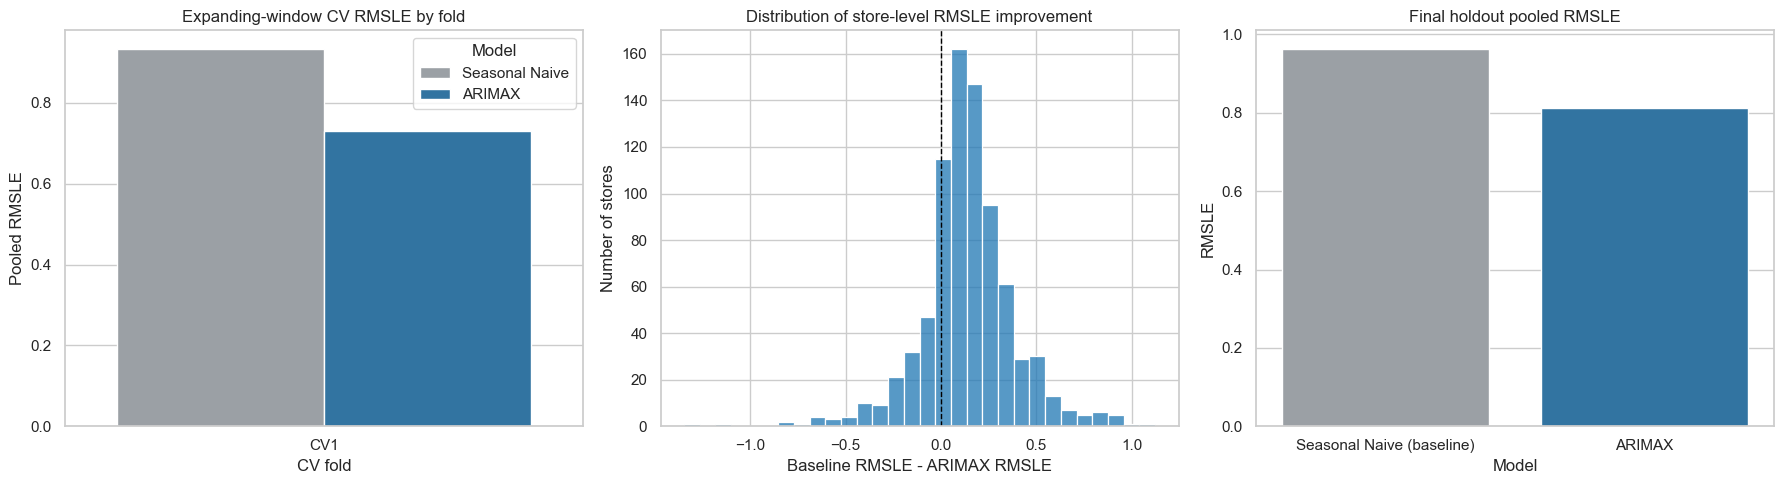

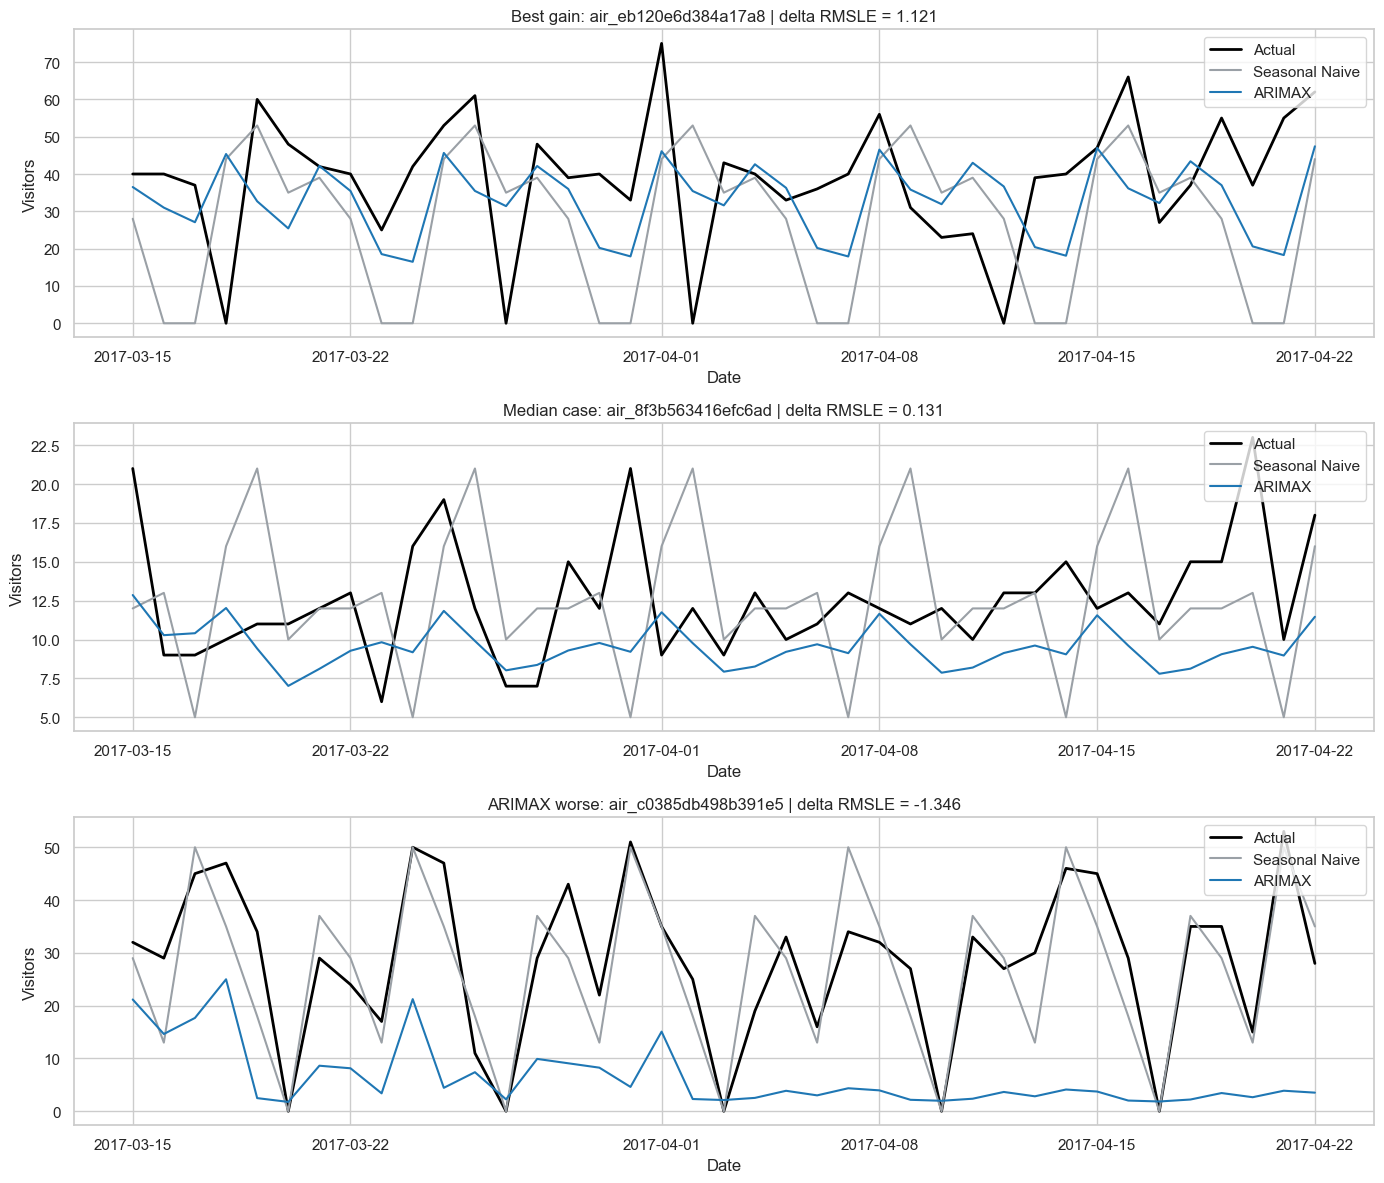

Saved updated outputs to ../output/store_level_*_v2.*


In [16]:
summary = {
    'n_stores_total': int(len(store_ids)),
    'n_stores_evaluated': int(len(store_metrics)),
    'n_stores_skipped': int(len(skipped_stores)),
    'n_failures': int(len(failures)),
    'holdout_start': str(final_holdout_start.date()),
    'holdout_end': str(final_holdout_end.date()),
    'pooled_rows': int(len(pooled_df)),
    'seasonal_naive_rmsle_pooled': rmsle(pooled_df['actual_visitors'], pooled_df['seasonal_naive_pred']),
    'arimax_rmsle_pooled': rmsle(pooled_df['actual_visitors'], pooled_df['arimax_pred']),
    'seasonal_naive_rmse_log_pooled': float(np.sqrt(np.mean((pooled_df['actual_log1p'] - pooled_df['seasonal_naive_log1p']) ** 2))),
    'arimax_rmse_log_pooled': float(np.sqrt(np.mean((pooled_df['actual_log1p'] - pooled_df['arimax_log1p']) ** 2))),
    'seasonal_naive_mape_pooled': float(np.mean(np.abs((pooled_df['actual_visitors'] - pooled_df['seasonal_naive_pred']) / np.clip(pooled_df['actual_visitors'], 1, None))) * 100.0),
    'arimax_mape_pooled': float(np.mean(np.abs((pooled_df['actual_visitors'] - pooled_df['arimax_pred']) / np.clip(pooled_df['actual_visitors'], 1, None))) * 100.0),
    'arimax_better_store_share': float((store_metrics['arimax_rmsle'] < store_metrics['seasonal_naive_rmsle']).mean()),
}
summary['improvement_vs_baseline_pct'] = 100.0 * (
    summary['seasonal_naive_rmsle_pooled'] - summary['arimax_rmsle_pooled']
) / summary['seasonal_naive_rmsle_pooled']

final_metrics = pd.DataFrame([
    {
        'model': 'Seasonal Naive (baseline)',
        'scope': 'pooled observed store-date holdout',
        'RMSLE': summary['seasonal_naive_rmsle_pooled'],
        'RMSE_log': summary['seasonal_naive_rmse_log_pooled'],
        'MAPE': summary['seasonal_naive_mape_pooled'],
    },
    {
        'model': 'ARIMAX',
        'scope': 'pooled observed store-date holdout',
        'RMSLE': summary['arimax_rmsle_pooled'],
        'RMSE_log': summary['arimax_rmse_log_pooled'],
        'MAPE': summary['arimax_mape_pooled'],
    },
])

summary_df = pd.DataFrame([summary]).T.rename(columns={0: 'value'})
store_metrics['delta_rmsle'] = store_metrics['seasonal_naive_rmsle'] - store_metrics['arimax_rmsle']
cv_plot_df = cv_summary_df.melt(
    id_vars=['split', 'n_stores_evaluated', 'pooled_rows', 'improvement_pct'],
    value_vars=['seasonal_naive_rmsle', 'arimax_rmsle'],
    var_name='model',
    value_name='rmsle',
)
cv_plot_df['model'] = cv_plot_df['model'].map({
    'seasonal_naive_rmsle': 'Seasonal Naive',
    'arimax_rmsle': 'ARIMAX',
})

display(summary_df)
display(final_metrics)
display(cv_summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cv_plot_df, x='split', y='rmsle', hue='model', ax=axes[0], palette=['#9aa0a6', '#1f77b4'])
axes[0].set_title('Expanding-window CV RMSLE by fold')
axes[0].set_xlabel('CV fold')
axes[0].set_ylabel('Pooled RMSLE')
axes[0].legend(title='Model')

sns.histplot(store_metrics['delta_rmsle'], bins=30, ax=axes[1], color='#1f77b4')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of store-level RMSLE improvement')
axes[1].set_xlabel('Baseline RMSLE - ARIMAX RMSLE')
axes[1].set_ylabel('Number of stores')

comparison_df = final_metrics[['model', 'RMSLE']].copy()
sns.barplot(data=comparison_df, x='model', y='RMSLE', ax=axes[2], palette=['#9aa0a6', '#1f77b4'])
axes[2].set_title('Final holdout pooled RMSLE')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('RMSLE')

plt.tight_layout()
plt.show()

representative = {
    'Best gain': store_metrics.sort_values('delta_rmsle', ascending=False).iloc[0]['air_store_id'],
    'Median case': store_metrics.iloc[(store_metrics['delta_rmsle'] - store_metrics['delta_rmsle'].median()).abs().argsort().iloc[0]]['air_store_id'],
    'ARIMAX worse': store_metrics.sort_values('delta_rmsle', ascending=True).iloc[0]['air_store_id'],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
for ax, (label, store_id) in zip(axes, representative.items()):
    store_plot = pooled_df.loc[pooled_df['air_store_id'] == store_id].copy()
    store_plot['visit_date'] = pd.to_datetime(store_plot['visit_date'])
    ax.plot(store_plot['visit_date'], store_plot['actual_visitors'], label='Actual', color='black', linewidth=2)
    ax.plot(store_plot['visit_date'], store_plot['seasonal_naive_pred'], label='Seasonal Naive', color='#9aa0a6')
    ax.plot(store_plot['visit_date'], store_plot['arimax_pred'], label='ARIMAX', color='#1f77b4')
    delta = float(store_metrics.loc[store_metrics['air_store_id'] == store_id, 'delta_rmsle'].iloc[0])
    ax.set_title(f'{label}: {store_id} | delta RMSLE = {delta:.3f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Visitors')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

cv_summary_df.to_csv(OUTPUT_DIR / 'store_level_cv_summary_v2.csv', index=False)
store_metrics.to_csv(OUTPUT_DIR / 'store_level_metrics_v2.csv', index=False)
pooled_df.to_csv(OUTPUT_DIR / 'store_level_holdout_predictions_v2.csv', index=False)
with open(OUTPUT_DIR / 'store_level_summary_v2.json', 'w', encoding='utf-8') as f:
    json.dump({**summary, 'cv_folds': cv_summary_df.to_dict(orient='records')}, f, ensure_ascii=False, indent=2)

print('Saved updated outputs to ../output/store_level_*_v2.*')



## Conclusion

The final notebook now supports a stronger project claim:

- the final ARIMAX model beats a strong weekly seasonal baseline on the last observed holdout
- expanding-window CV checks that the improvement is not based on only one split
- result plots make it easier to interpret where ARIMAX helps and where it still struggles

This is a more defensible final artifact for grading because it combines methodology, validation, final evaluation, interpretation, and saved outputs in one place under `../output/`.



In [17]:
print('Updated outputs saved in ../output')
print('ARIMAX failures:', len(failures))
print('Skipped stores :', len(skipped_stores))
if len(skipped_stores):
    display(skipped_df.head())



Updated outputs saved in ../output
ARIMAX failures: 0
Skipped stores : 2


,air_store_id,train_days,test_days,reason
0,air_0ead98dd07e7a82a,250,0,insufficient_train_or_no_test_rows
1,air_cb083b4789a8d3a2,306,0,insufficient_train_or_no_test_rows
